In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
df = pd.read_csv("../data/processed/flights_sample_3m_week2_eda.csv")
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,DAY_OF_WEEK,DEP_HOUR,Route
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,1065.0,NaN,NaN,NaN,NaN,NaN,1,2,11.0,FLL-EWR
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,1399.0,NaN,NaN,NaN,NaN,NaN,11,5,21.0,MSP-SEA
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,680.0,NaN,NaN,NaN,NaN,NaN,7,4,10.0,DEN-MSP
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,1589.0,0.0,0.0,24.0,0.0,0.0,3,0,16.0,MSP-SFO
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,985.0,NaN,NaN,NaN,NaN,NaN,2,6,18.0,MCO-DFW


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 36 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [4]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

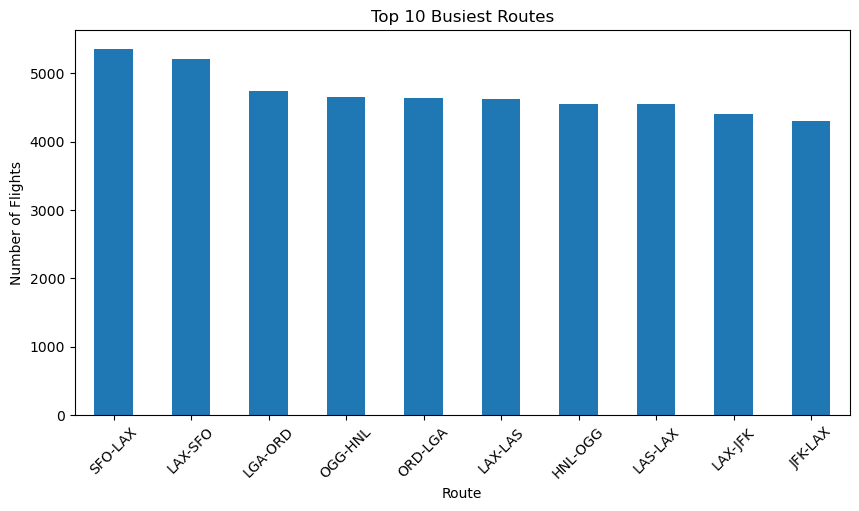

In [5]:
import matplotlib.pyplot as plt
top_routes = df['Route'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_routes.plot(kind='bar')
plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

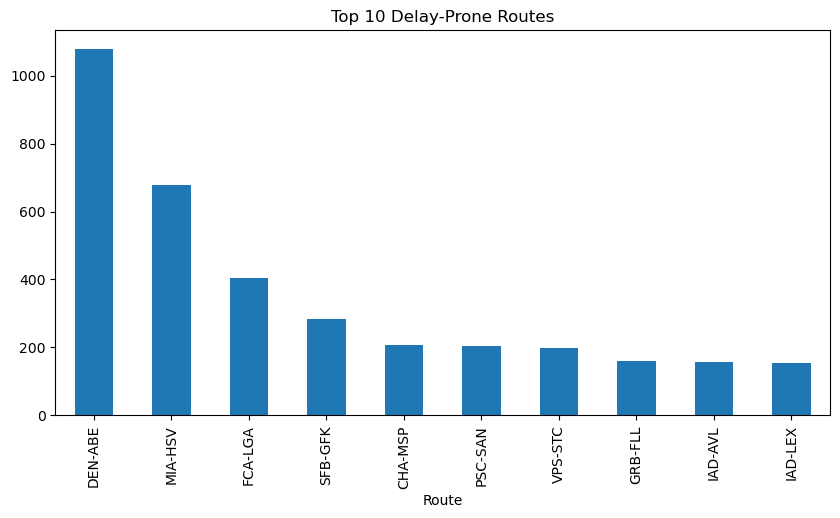

In [6]:
route_delay = df.groupby('Route')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
route_delay.plot(kind='bar')
plt.title("Top 10 Delay-Prone Routes")
plt.show()

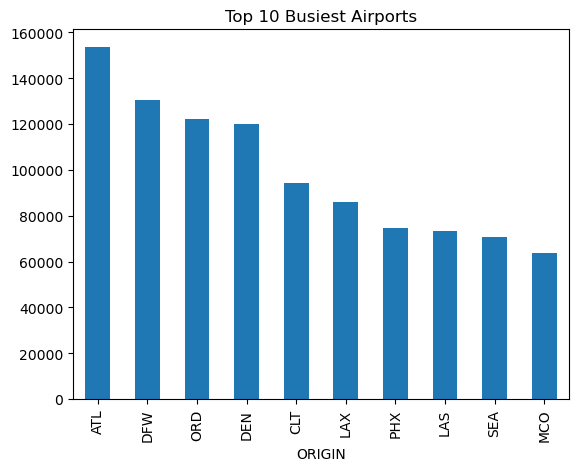

In [7]:
top_airports = df['ORIGIN'].value_counts().head(10)
top_airports.plot(kind='bar', title="Top 10 Busiest Airports")
plt.show()

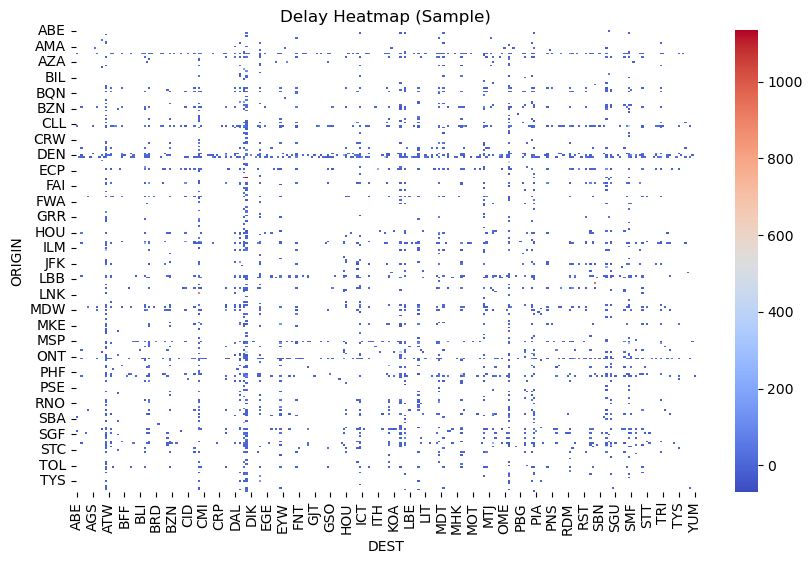

In [8]:
import seaborn as sns
sample_df = df.sample(5000)
pivot = sample_df.pivot_table(values='ARR_DELAY', index='ORIGIN', columns='DEST', aggfunc='mean')
plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Delay Heatmap (Sample)")
plt.show()

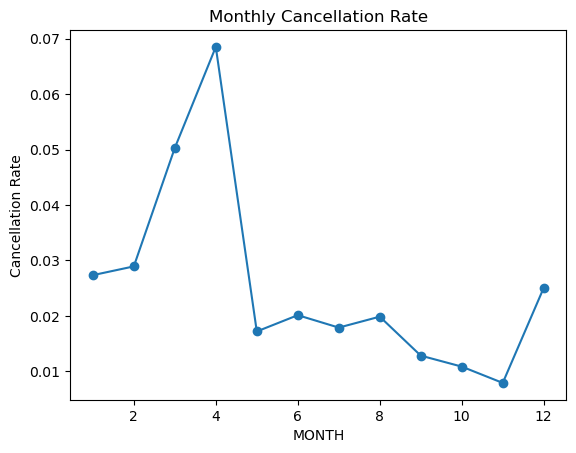

In [9]:
monthly_cancel = df.groupby('MONTH')['CANCELLED'].mean()
monthly_cancel.plot(marker='o', title="Monthly Cancellation Rate")
plt.ylabel("Cancellation Rate")
plt.show()

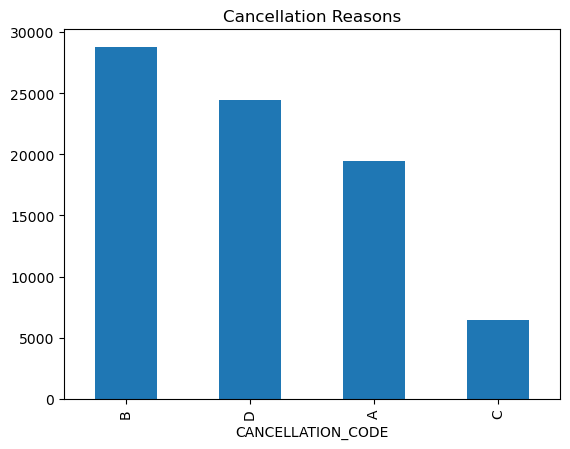

In [10]:
df['CANCELLATION_CODE'].value_counts().plot(kind='bar', title="Cancellation Reasons")
plt.show()

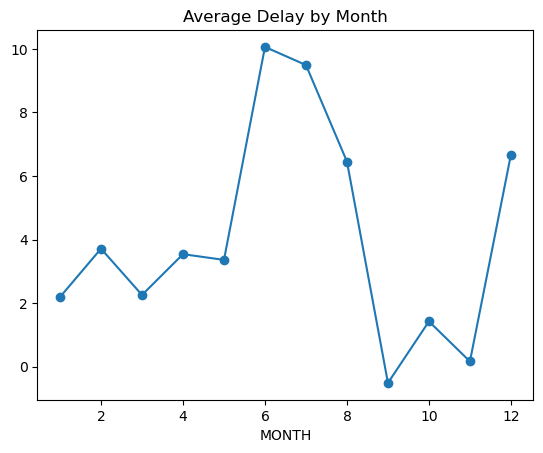

In [11]:
df.groupby('MONTH')['ARR_DELAY'].mean().plot(marker='o', title="Average Delay by Month")
plt.show()

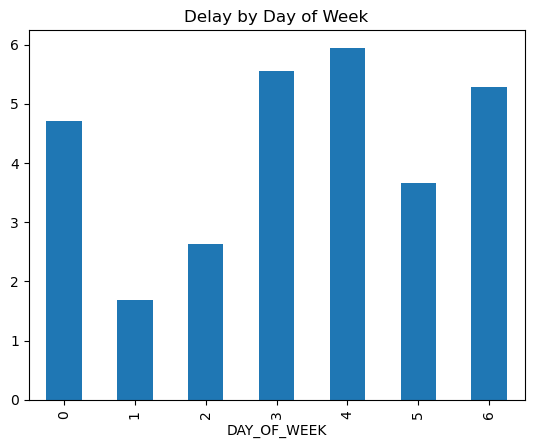

In [12]:
df.groupby('DAY_OF_WEEK')['ARR_DELAY'].mean().plot(kind='bar', title="Delay by Day of Week")
plt.show()

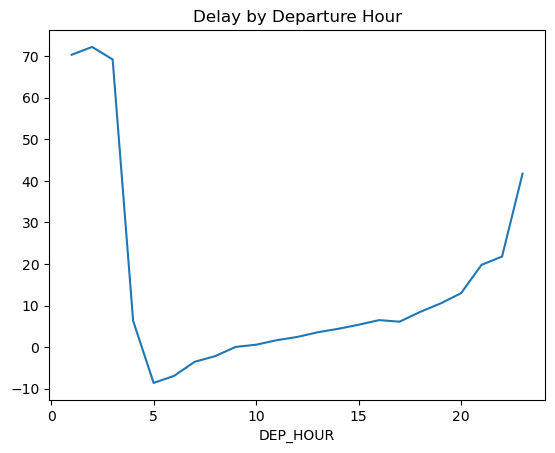

In [13]:
df.groupby('DEP_HOUR')['ARR_DELAY'].mean().plot(title="Delay by Departure Hour")
plt.show()

In [14]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"
df['SEASON'] = df['MONTH'].apply(get_season)

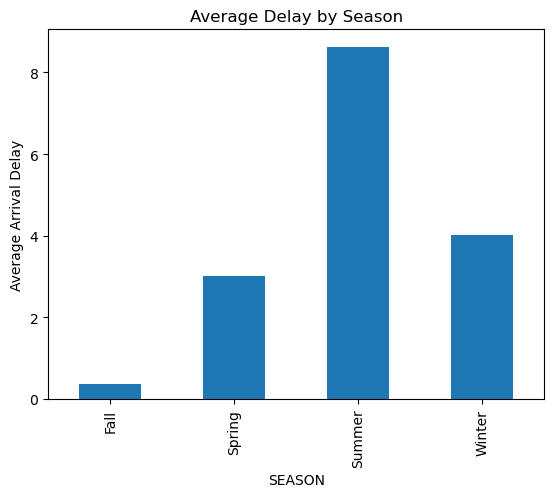

In [15]:
import matplotlib.pyplot as plt
df.groupby('SEASON')['ARR_DELAY'].mean().plot(kind='bar')
plt.title("Average Delay by Season")
plt.ylabel("Average Arrival Delay")
plt.show()

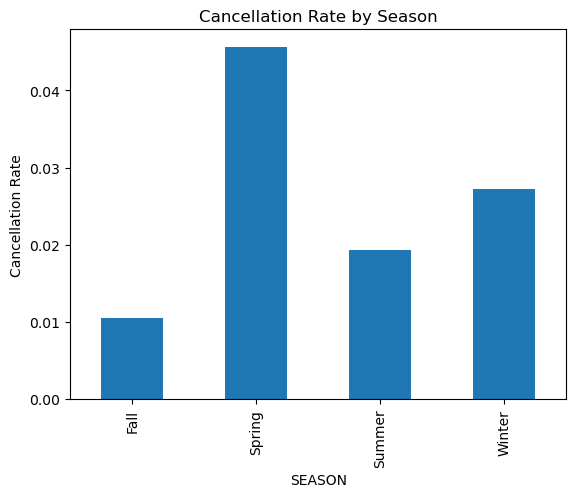

In [16]:
df.groupby('SEASON')['CANCELLED'].mean().plot(kind='bar')
plt.title("Cancellation Rate by Season")
plt.ylabel("Cancellation Rate")
plt.show()

In [18]:
holiday_df = df[df['MONTH'] == 12]
holiday_df['ARR_DELAY'].mean(), holiday_df['CANCELLED'].mean()

(np.float64(6.67248358026577), np.float64(0.025061632673906282))

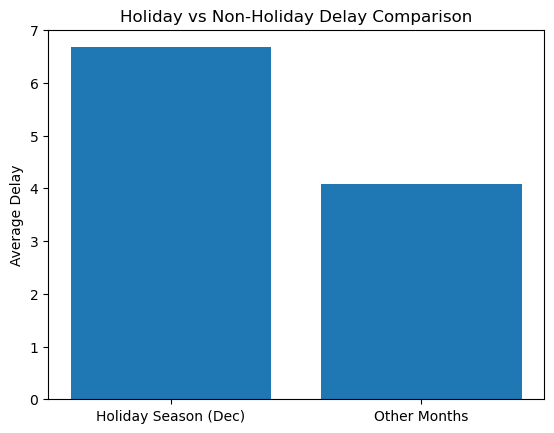

In [19]:
labels = ['Holiday Season (Dec)', 'Other Months']
delay_values = [
    holiday_df['ARR_DELAY'].mean(),
    df[df['MONTH'] != 12]['ARR_DELAY'].mean()
]

plt.bar(labels, delay_values)
plt.title("Holiday vs Non-Holiday Delay Comparison")
plt.ylabel("Average Delay")
plt.show()

In [21]:
df.to_csv("../data/processed/flights_sample_3m_week3_final.csv", index=False)